In [1]:
from pathlib import Path
import json
import pandas as pd

import pyarrow as pa
import pyarrow.parquet as pq
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

c:\ProgramData\anaconda3\envs\OB\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load RBSA III Sites (2022)

Read site metadata and keep only sites from `rbsa_version == "2022"`.

In [2]:
SITES_PATH = Path("../src/data/metadata/SITES v9.2.csv")

sites_meta = pd.read_csv(SITES_PATH, dtype=str)
sites_rbsa_2022 = sites_meta[sites_meta["rbsa_version"] == "2022"].reset_index(drop=True)

print(f"Total sites: {len(sites_meta):,}")
print(f"RBSA 2022 sites: {len(sites_rbsa_2022):,}")
display(sites_rbsa_2022)

Total sites: 419
RBSA 2022 sites: 133


,site_id,ee_site_id,state,hz,cz,tz_abbr,tz_utc_offset,station_id,rbsa_site_id,rbsa_version
0,RBSA2022_308069,308069,WA,2,2,PST,-8,999999-4136,SITE_1096,2022
1,RBSA2022_650217,650217,WA,2,2,PST,-8,727856-94176,SITE_1546,2022
2,RBSA2022_183932,183932,WA,1,1,PST,-8,742060-24207,SITE_572,2022
3,RBSA2022_216927,216927,ID,1,3,MST,-7,726813-94195,SITE_734,2022
4,RBSA2022_256399,256399,ID,1,3,MST,-7,726813-94195,SITE_883,2022
...,...,...,...,...,...,...,...,...,...,...
128,RBSA2022_236818,236818,WA,1,3,PST,-8,727884-99999,SITE_805,2022
129,RBSA2022_630128,30128,WA,2,2,PST,-8,727856-94176,SITE_1467,2022
130,RBSA2022_646691,46691,WA,2,2,PST,-8,727856-94176,SITE_1534,2022
131,RBSA2022_626709,26709,WA,2,2,PST,-8,727850-24157,SITE_1455,2022


weather data

In [5]:
station_out = Path("../src/data/metadata") / "rbsa3_2022_station_ids.csv"

(
    sites_rbsa_2022[["station_id"]]
    .drop_duplicates()
    .sort_values("station_id")
    .reset_index(drop=True)
    .to_csv(station_out, index=False)
)

print(f"Saved {sites_rbsa_2022['station_id'].nunique()} unique station IDs to {station_out.name}")

Saved 36 unique station IDs to rbsa3_2022_station_ids.csv


## 2. Load Raw 15-Minute Power Data for RBSA 2022 Sites

Read `POWER15_RAW_2023 v9.2.csv` in chunks (same source as `proc.ipynb`),
filter to the 133 RBSA 2022 sites, and save one parquet per site.
Files are named by `site_id` and written to `../src/data/sites/rbsa3/`.

In [ ]:

RAW_POWER_FILE = Path("../POWER15_RAW_2023 v9.2.csv")
SITES_RBSA3_DIR = Path("../src/data/sites/rbsa3")
RAW_CHUNKSIZE = 250_000
OVERWRITE = True

SITES_RBSA3_DIR.mkdir(parents=True, exist_ok=True)


In [33]:

# Build ee_site_id -> site_id mapping for RBSA 2022 sites
valid_ee_ids = set(sites_rbsa_2022["ee_site_id"].astype(int))
ee_to_site = dict(
    zip(sites_rbsa_2022["ee_site_id"].astype(int), sites_rbsa_2022["rbsa_site_id"])
)

if OVERWRITE:
    for site_id in ee_to_site.values():
        p = SITES_RBSA3_DIR / f"{site_id}.parquet"
        if p.exists():
            p.unlink()

# Skip sites whose parquet already exists
ee_ids_to_process = {
    ee_id for ee_id, site_id in ee_to_site.items()
    if not (SITES_RBSA3_DIR / f"{site_id}.parquet").exists()
}
print(f"Already saved: {len(valid_ee_ids) - len(ee_ids_to_process):,} sites (skipping)")
print(f"To process   : {len(ee_ids_to_process):,} sites")

writers, schema_map, rows_by_site = {}, {}, {}

if ee_ids_to_process:
    try:
        for chunk in tqdm(pd.read_csv(RAW_POWER_FILE, chunksize=RAW_CHUNKSIZE), desc="Reading POWER15"):
            filtered = chunk[chunk["ee_site_id"].isin(ee_ids_to_process)]
            if filtered.empty:
                continue
            for ee_id, group in filtered.groupby("ee_site_id"):
                ee_id = int(ee_id)
                site_id = ee_to_site[ee_id]
                out_path = SITES_RBSA3_DIR / f"{site_id}.parquet"
                table = pa.Table.from_pandas(group, preserve_index=False)
                if ee_id not in writers:
                    schema_map[ee_id] = table.schema
                    writers[ee_id] = pq.ParquetWriter(out_path, table.schema)
                    rows_by_site[ee_id] = 0
                else:
                    table = table.cast(schema_map[ee_id])
                writers[ee_id].write_table(table)
                rows_by_site[ee_id] += len(group)
    finally:
        for w in writers.values():
            w.close()

summary = (
    pd.DataFrame([
        {"site_id": ee_to_site[ee_id], "ee_site_id": ee_id, "rows": rows}
        for ee_id, rows in rows_by_site.items()
    ])
    .sort_values("site_id")
    .reset_index(drop=True)
)

print(f"RBSA 2022 sites requested: {len(valid_ee_ids):,}")
print(f"Newly saved in this run:   {len(summary):,}")
print(f"Total rows saved:          {summary['rows'].sum():,}")
display(summary)


Already saved: 0 sites (skipping)
To process   : 133 sites


Reading POWER15: 0it [00:00, ?it/s]

Reading POWER15: 839it [10:31,  1.33it/s]


RBSA 2022 sites requested: 133
Newly saved in this run:   112
Total rows saved:          69,461,326


,site_id,ee_site_id,rows
0,SITE_1023,292998,16296
1,SITE_1036,295578,1010835
2,SITE_1049,298259,365379
3,SITE_105,113763,838344
4,SITE_1053,299113,593980
5,SITE_107,113900,279520
6,SITE_1080,303645,912833
7,SITE_1087,306108,663860
8,SITE_1094,307473,34314
9,SITE_1096,308069,733740


## 3. Unique End Uses Across RBSA 2022 Sites


In [16]:
end_use_site_count = {}
end_use_row_count = {}

for path in sorted(SITES_RBSA3_DIR.glob("*.parquet")):
    df = pd.read_parquet(path, columns=["End Use"])
    for eu, count in df["End Use"].value_counts().items():
        end_use_site_count[eu] = end_use_site_count.get(eu, 0) + 1
        end_use_row_count[eu] = end_use_row_count.get(eu, 0) + count

end_use_summary = (
    pd.DataFrame({
        "end_use": list(end_use_site_count),
        "n_sites": [end_use_site_count[k] for k in end_use_site_count],
        "n_rows": [end_use_row_count[k] for k in end_use_site_count],
    })
    .sort_values("n_sites", ascending=False)
    .reset_index(drop=True)
)

print(f"Unique end uses: {len(end_use_summary):,}")
display(end_use_summary)

Unique end uses: 33


,end_use,n_sites,n_rows
0,Other,112,33633152
1,Clothes Dryer,103,3239869
2,Stove/Oven/Range,101,3567858
3,Mains,97,2927616
4,Clothes Washer,90,2791279
5,Dishwasher,78,2407380
6,Microwave,64,1980532
7,Refrigerator/Freezer,63,2425404
8,Electric Resistance Storage Water Heaters,60,1836516
9,Garbage Disposal,49,1458116


## 4. Map End Uses to Load Categories


In [21]:
END_USE_CATEGORY_MAP = {
    # Overall
    "Mains":              "Overall",
    "Mains With Solar":   "Overall",
    "Sub Panel":          "Overall",
    "EULR BOX":           "Overall",
    # DHW
    "Electric Resistance Storage Water Heaters": "DHW",
    "Heat Pump Water Heater":                   "DHW",
    "Instantaneous Water Heater (Gas)":         "DHW",
    "Instantaneous Water Heater (Elec)":        "DHW",
    # Heating
    "Gas Furnace (Component)":   "Heating",
    "Electric Furnace":          "Heating",
    "Other Zonal Heat":          "Heating",
    "Electric Baseboard Heaters":"Heating",
    "Ducted Heatpump":           "Heating",
    "Ductless Heatpump":         "Heating",
    # Cooling
    "Central AC":  "Cooling",
    "Room AC":     "Cooling",
    "PTAC":        "Cooling",
    # Equipment
    "Clothes Dryer":         "Equipment",
    "Stove/Oven/Range":      "Equipment",
    "Clothes Washer":        "Equipment",
    "Dishwasher":            "Equipment",
    "Microwave":             "Equipment",
    "Refrigerator/Freezer":  "Equipment",
    "Garbage Disposal":      "Equipment",
    "Hot Tub":               "Equipment",
    "Central Vacuum":        "Equipment",
    "EVSE":                  "Equipment",
    "PUMP":                  "Equipment",
    "Pump":                  "Equipment",
    "Other Large Load":      "Equipment",
    "Ignitor":               "Equipment",
    # Renewable
    "Solar": "Renewable",
    # Other
    "Other": "Other",
}

end_use_summary["category"] = end_use_summary["end_use"].map(END_USE_CATEGORY_MAP)

unmapped = end_use_summary[end_use_summary["category"].isna()]["end_use"].tolist()
if unmapped:
    print("Unmapped end uses:", unmapped)

category_summary = (
    end_use_summary.groupby("category", dropna=False)
    [["n_sites", "n_rows"]].sum()
    .sort_values("n_sites", ascending=False)
)

display(end_use_summary[["end_use", "category", "n_sites", "n_rows"]])
print("\nCategory rollup:")
display(category_summary)

# Save mapping to rbsa3 folder
EU_MAP_PATH =  "../src/data/sites/end_use_category_map_3.json"
with open(EU_MAP_PATH, "w") as f:
    json.dump(END_USE_CATEGORY_MAP, f, indent=4)
print(f"Saved end use category map to {EU_MAP_PATH}")


,end_use,category,n_sites,n_rows
0,Other,Other,112,33633152
1,Clothes Dryer,Equipment,103,3239869
2,Stove/Oven/Range,Equipment,101,3567858
3,Mains,Overall,97,2927616
4,Clothes Washer,Equipment,90,2791279
5,Dishwasher,Equipment,78,2407380
6,Microwave,Equipment,64,1980532
7,Refrigerator/Freezer,Equipment,63,2425404
8,Electric Resistance Storage Water Heaters,DHW,60,1836516
9,Garbage Disposal,Equipment,49,1458116



Category rollup:


,n_sites,n_rows
category,,
Equipment,611,19900940
Heating,174,7903094
Overall,134,4071159
Other,112,33633152
DHW,70,2169144
Cooling,38,1233757
Renewable,6,202865


Saved end use category map to ../src/data/sites/end_use_category_map_3.json


## 3. Per-Site Load Curves

Load one site parquet and plot every circuit as a separate color over the full year.
Set `TARGET_SITE_ID` to any filename stem in `sites/rbsa3/`.

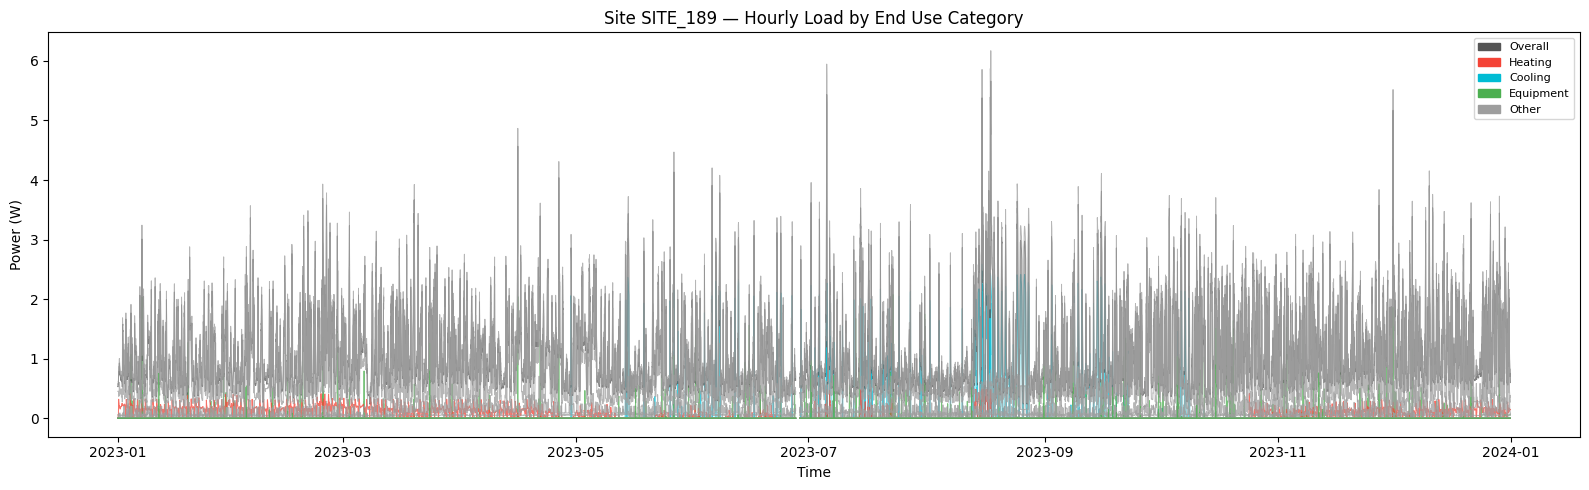

Site: SITE_189
Circuits: 23
category
Equipment    9
Other        9
Cooling      2
Heating      2
Overall      1
Name: n_circuits, dtype: int64


In [49]:

TARGET_SITE_ID = sorted(SITES_RBSA3_DIR.glob("*.parquet"))[35].stem

CATEGORY_COLORS = {
    "Overall":   "#555555",
    "DHW":       "#2196F3",
    "Heating":   "#F44336",
    "Cooling":   "#00BCD4",
    "Equipment": "#4CAF50",
    "Lighting":  "#FFC107",
    "Renewable": "#8BC34A",
    "Other":     "#9E9E9E",
}

df = pd.read_parquet(SITES_RBSA3_DIR / f"{TARGET_SITE_ID}.parquet")
df["MIN_T_l"] = pd.to_datetime(df["MIN_T_l"], errors="coerce")
df["power"]   = pd.to_numeric(df["power"], errors="coerce")
df["category"] = df["End Use"].map(END_USE_CATEGORY_MAP).fillna("Other")

fig, ax = plt.subplots(figsize=(16, 5))

for circuit, sub_df in df.groupby("Circuit Label"):
    category = sub_df["category"].iloc[0]
    color = CATEGORY_COLORS.get(category, "#9E9E9E")
    hourly = (
        sub_df.set_index("MIN_T_l")["power"]
        .resample("1h").mean()
    )
    ax.plot(hourly.index, hourly.values, lw=0.7, alpha=0.75, color=color)

legend_handles = [
    mpatches.Patch(color=color, label=cat)
    for cat, color in CATEGORY_COLORS.items()
    if cat in df["category"].values
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=8, framealpha=0.8)
ax.set_title(f"Site {TARGET_SITE_ID} — Hourly Load by End Use Category")
ax.set_xlabel("Time")
ax.set_ylabel("Power (W)")
plt.tight_layout()
plt.show()

print(f"Site: {TARGET_SITE_ID}")
print(f"Circuits: {df['Circuit Label'].nunique()}")
print(df.groupby('category')['Circuit Label'].nunique().rename('n_circuits').sort_values(ascending=False))

## 5. Calculated Sum per Site

For each timestamp, sum power across all circuits **excluding** `Overall` and `Other`.
Null rule: if every circuit is null at a timestep → NaN; if any is non-null → fill nulls with 0 and sum.
Appends a `calculated_sum` circuit row to each site parquet, then combines all sites into one file.

In [43]:
COMBINED_PATH = SITES_RBSA3_DIR / "calculated_sum_all_sites.parquet"
EXCLUDE_CATEGORIES = {"Overall", "Renewable"}

all_calc_sums = []

parquet_files = [
    p for p in sorted(SITES_RBSA3_DIR.glob("*.parquet"))
    if p.name != "calculated_sum_all_sites.parquet"
]

for path in tqdm(parquet_files, desc="Computing calculated_sum"):
    df = pd.read_parquet(path)
    df["MIN_T_l"] = pd.to_datetime(df["MIN_T_l"], errors="coerce")
    df["power"]   = pd.to_numeric(df["power"], errors="coerce")
    df["category"] = df["End Use"].map(END_USE_CATEGORY_MAP).fillna("Other")

    # Drop any previously computed calculated_sum rows before recomputing
    df_clean = df[df["Circuit Label"] != "calculated_sum"].copy()

    # Pivot non-excluded circuits: rows=timestamp, cols=circuit
    valid = df_clean[~df_clean["category"].isin(EXCLUDE_CATEGORIES)]
    pivot = valid.pivot_table(
        index="MIN_T_l", columns="Circuit Label", values="power", aggfunc="mean"
    )

    # Null rule
    all_null = pivot.isna().all(axis=1)
    calc_sum = pivot.fillna(0).sum(axis=1)
    calc_sum[all_null] = np.nan

    # Build new rows matching the site parquet schema
    orig_cols = [c for c in df_clean.columns if c != "category"]
    base = df_clean.iloc[0]
    calc_rows = pd.DataFrame({"MIN_T_l": calc_sum.index, "power": calc_sum.values})
    for col in orig_cols:
        if col in ("MIN_T_l", "power"):
            continue
        elif col == "Circuit Label":
            calc_rows[col] = "calculated_sum"
        elif col == "End Use":
            calc_rows[col] = "calculated_sum"
        elif col in ("state", "hz", "cz", "ee_site_id"):
            calc_rows[col] = base[col]
        else:
            calc_rows[col] = np.nan

    # Append and save back
    updated = pd.concat([df_clean[orig_cols], calc_rows[orig_cols]], ignore_index=True)
    updated.to_parquet(path, index=False)

    # Collect for combined file
    all_calc_sums.append(
        calc_rows[["ee_site_id", "MIN_T_l", "power"]]
        .assign(site_id=path.stem)
    )

combined = pd.concat(all_calc_sums, ignore_index=True)
combined.to_parquet(COMBINED_PATH, index=False)

print(f"Updated {len(parquet_files):,} site parquets with calculated_sum circuit")
print(f"Combined file: {COMBINED_PATH} ({len(combined):,} rows, {combined['site_id'].nunique():,} sites)")
display(combined.head(10))

Computing calculated_sum: 100%|██████████| 112/112 [02:36<00:00,  1.40s/it]


Updated 112 site parquets with calculated_sum circuit
Combined file: ..\src\data\sites\rbsa3\calculated_sum_all_sites.parquet (3,393,154 rows, 112 sites)


,ee_site_id,MIN_T_l,power,site_id
0,292998,2023-12-18 11:00:00,0.798,SITE_1023
1,292998,2023-12-18 11:15:00,5.244,SITE_1023
2,292998,2023-12-18 11:30:00,0.822,SITE_1023
3,292998,2023-12-18 11:45:00,5.295,SITE_1023
4,292998,2023-12-18 12:00:00,0.705,SITE_1023
5,292998,2023-12-18 12:15:00,3.827,SITE_1023
6,292998,2023-12-18 12:30:00,1.811,SITE_1023
7,292998,2023-12-18 12:45:00,1.655,SITE_1023
8,292998,2023-12-18 13:00:00,4.323,SITE_1023
9,292998,2023-12-18 13:15:00,0.627,SITE_1023


In [44]:
combined = pd.read_parquet(COMBINED_PATH)
combined["MIN_T_l"] = pd.to_datetime(combined["MIN_T_l"], errors="coerce")
combined["power"]   = pd.to_numeric(combined["power"], errors="coerce")

# Full expected 15-min grid for the year
year = combined["MIN_T_l"].dt.year.mode()[0]
full_index = pd.date_range(f"{year}-01-01", f"{year}-12-31 23:45", freq="15min")

def quality_metrics(grp):
    # Reindex to full year so missing timestamps count as NaN
    s = grp.set_index("MIN_T_l")["power"].reindex(full_index)
    n = len(s)
    n_nan  = s.isna().sum()
    n_zero = (s == 0).sum()
    n_neg  = (s < 0).sum()
    return pd.Series({
        "n_expected"    : n,
        "n_present"     : int(grp["power"].notna().sum()),
        "nan_rate"      : n_nan  / n,
        "zero_rate"     : n_zero / n,
        "negative_rate" : n_neg  / n,
    })

metrics = (
    combined.groupby("site_id")
    .apply(quality_metrics)
    .reset_index()
    .sort_values("nan_rate", ascending=False)
)

print(f"Sites: {metrics['site_id'].nunique():,}  |  "
      f"Expected timesteps per site: {len(full_index):,}")
print(f"\nFleet-wide NaN rate      (incl. missing rows): "
      f"{1 - combined['power'].notna().sum() / (len(full_index) * metrics['site_id'].nunique()):.2%}")
print(f"Fleet-wide zero rate    : {(combined['power'] == 0).mean():.2%}")
print(f"Fleet-wide negative rate: {(combined['power'] < 0).mean():.2%}")
display(metrics)

Sites: 112  |  Expected timesteps per site: 35,040

Fleet-wide NaN rate      (incl. missing rows): 13.54%
Fleet-wide zero rate    : 0.15%
Fleet-wide negative rate: 0.00%


,site_id,n_expected,n_present,nan_rate,zero_rate,negative_rate
99,SITE_818,35040.0,280.0,0.992009,0.001684,0.0
24,SITE_1325,35040.0,379.0,0.989184,0.000000,0.0
0,SITE_1023,35040.0,776.0,0.977854,0.000000,0.0
8,SITE_1094,35040.0,1634.0,0.953368,0.000000,0.0
27,SITE_1354,35040.0,3337.0,0.904766,0.000000,0.0
87,SITE_650,35040.0,7582.0,0.783619,0.000000,0.0
51,SITE_232,35040.0,8603.0,0.754481,0.000000,0.0
45,SITE_158,35040.0,9652.0,0.724543,0.000000,0.0
19,SITE_1285,35040.0,13641.0,0.610702,0.003368,0.0
56,SITE_284,35040.0,14394.0,0.589212,0.000000,0.0


## 7. Move High-Missing-Rate Sites

Sites with `nan_rate >= 0.05` are moved to `sites/rbsa3/high_missing_rate/`.

In [46]:
MISSING_RATE_THRESHOLD = 0.04
HIGH_MISSING_DIR = SITES_RBSA3_DIR / "high_missing_rate"
HIGH_MISSING_DIR.mkdir(exist_ok=True)

high_missing = metrics[metrics["nan_rate"] >= MISSING_RATE_THRESHOLD]["site_id"].tolist()

moved, missing_src = [], []
for site_id in high_missing:
    src = SITES_RBSA3_DIR / f"{site_id}.parquet"
    dst = HIGH_MISSING_DIR / f"{site_id}.parquet"
    if src.exists():
        src.rename(dst)
        moved.append(site_id)
    else:
        missing_src.append(site_id)

print(f"Moved {len(moved):,} / {len(high_missing):,} sites "
      f"(nan_rate >= {MISSING_RATE_THRESHOLD:.0%}) to {HIGH_MISSING_DIR.name}/")
if missing_src:
    print(f"Source not found for: {missing_src}")
display(metrics[metrics["site_id"].isin(moved)][["site_id", "nan_rate", "n_present", "n_expected"]])

Moved 1 / 36 sites (nan_rate >= 4%) to high_missing_rate/
Source not found for: ['SITE_818', 'SITE_1325', 'SITE_1023', 'SITE_1094', 'SITE_1354', 'SITE_650', 'SITE_232', 'SITE_158', 'SITE_1285', 'SITE_284', 'SITE_1049', 'SITE_457', 'SITE_653', 'SITE_1562', 'SITE_867', 'SITE_372', 'SITE_311', 'SITE_1514', 'SITE_1499', 'SITE_4', 'SITE_742', 'SITE_154', 'SITE_974', 'SITE_710', 'SITE_9', 'SITE_926', 'SITE_418', 'SITE_1141', 'SITE_1146', 'SITE_846', 'SITE_559', 'SITE_734', 'SITE_1553', 'SITE_1102', 'SITE_643']


,site_id,nan_rate,n_present,n_expected
52,SITE_246,0.040354,33626.0,35040.0


## 8. Monthly Energy Totals by Category

For each quality-valid site, compute monthly kWh totals for every end use category
(DHW, Heating, Cooling, Equipment, Lighting, Other, Overall, Renewable),
plus `calculated_sum_kWh` (all categories except Overall & Renewable).

Energy = power (W) × 15 min × (1 hr / 60 min) × (1 kWh / 1000 Wh). NaN readings are excluded from the sum (treated as missing, not zero).

In [50]:
MONTHLY_DIR = SITES_RBSA3_DIR / "monthly_totals"
MONTHLY_DIR.mkdir(exist_ok=True)

INTERVAL_HRS = 15 / 60          # 15-minute readings
#WH_TO_KWH    = 1 / 1000
ENERGY_FACTOR = INTERVAL_HRS #* WH_TO_KWH

ALL_CATEGORIES = ["DHW", "Heating", "Cooling", "Equipment", "Lighting",
                  "Other", "Overall", "Renewable"]
SUM_CATEGORIES = [c for c in ALL_CATEGORIES if c not in {"Overall", "Renewable"}]

# Valid sites = those still in rbsa3/ root (not moved to high_missing_rate/)
valid_parquets = [
    p for p in sorted(SITES_RBSA3_DIR.glob("*.parquet"))
    if p.name not in {"calculated_sum_all_sites.parquet"}
]

monthly_records = []

for path in tqdm(valid_parquets, desc="Monthly totals"):
    df = pd.read_parquet(path)
    df = df[df["Circuit Label"] != "calculated_sum"].copy()
    df["MIN_T_l"] = pd.to_datetime(df["MIN_T_l"], errors="coerce")
    df["power"]   = pd.to_numeric(df["power"], errors="coerce")
    df["category"] = df["End Use"].map(END_USE_CATEGORY_MAP).fillna("Other")
    df["month"] = df["MIN_T_l"].dt.to_period("M")

    # Monthly kWh per category (NaN rows skipped by skipna=True)
    monthly_cat = (
        df.groupby(["month", "category"])["power"]
        .sum()
        .multiply(ENERGY_FACTOR)
        .unstack("category")
        .reindex(columns=ALL_CATEGORIES, fill_value=0)
    )

    monthly_cat["calculated_sum_kWh"] = monthly_cat[SUM_CATEGORIES].sum(axis=1)
    monthly_cat.columns = [
        f"{c}_kWh" if c in ALL_CATEGORIES else c
        for c in monthly_cat.columns
    ]
    monthly_cat = monthly_cat.reset_index()
    monthly_cat["month"] = monthly_cat["month"].astype(str)
    monthly_cat.insert(0, "site_id", path.stem)

    monthly_cat.to_parquet(MONTHLY_DIR / f"{path.stem}.parquet", index=False)
    monthly_records.append(monthly_cat)

monthly_all = pd.concat(monthly_records, ignore_index=True)
monthly_all.to_parquet(MONTHLY_DIR / "monthly_totals_all_sites.parquet", index=False)

print(f"Saved {len(valid_parquets):,} site monthly parquets to {MONTHLY_DIR.name}/")
print(f"Combined: {len(monthly_all):,} rows  ({monthly_all['site_id'].nunique():,} sites × ~12 months)")
display(monthly_all.head(12))

Monthly totals: 100%|██████████| 76/76 [00:32<00:00,  2.33it/s]

Saved 76 site monthly parquets to monthly_totals/
Combined: 912 rows  (76 sites × ~12 months)


,site_id,month,DHW_kWh,Heating_kWh,Cooling_kWh,Equipment_kWh,Lighting_kWh,Other_kWh,Overall_kWh,Renewable_kWh,calculated_sum_kWh
0,SITE_1036,2023-01,0.0,68.52200,1.57550,647.39100,0,1471.12375,1635.16100,-171.00300,2188.61225
1,SITE_1036,2023-02,0.0,62.64200,1.33400,558.39500,0,666.76250,587.58000,-319.98175,1289.13350
2,SITE_1036,2023-03,0.0,56.06675,1.46950,570.24925,0,708.33400,550.59225,-383.35425,1336.11950
3,SITE_1036,2023-04,0.0,29.66675,6.83625,385.98775,0,795.38575,11.49400,-619.59550,1217.87650
4,SITE_1036,2023-05,0.0,31.25000,126.29375,327.62175,0,921.86100,-11.40900,-737.84225,1407.02650
5,SITE_1036,2023-06,0.0,43.90125,193.27425,323.05325,0,963.50775,106.89275,-745.88775,1523.73650
6,SITE_1036,2023-07,0.0,129.99750,680.41125,232.19975,0,1077.98100,475.02250,-827.64600,2120.58950
7,SITE_1036,2023-08,0.0,105.21425,529.39175,251.25025,0,991.35050,429.21675,-674.01800,1877.20675
8,SITE_1036,2023-09,0.0,91.93900,210.88675,352.27075,0,877.23750,292.08400,-572.92400,1532.33400
9,SITE_1036,2023-10,0.0,293.13925,28.87275,337.47600,0,615.30775,486.50300,-418.96050,1274.79575


In [48]:
monthly_all.to_csv(MONTHLY_DIR / "monthly_totals_all_sites.parquet", index=False)